# Analise de Consumo de Energia em Edificacoes

Notebook principal de estudo do dataset `household_power_consumption.txt` com foco em:

- carga e limpeza dos dados;
- criacao de atributos temporais e energeticos;
- estatistica descritiva;
- sazonalidade;
- correlacao, regimes e anomalias;
- preparo de tabelas para futura interpretacao por LLM.


In [1]:
# =========================
# 1. Configuracao inicial
# =========================

import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

CAMINHO_DADOS = Path("../data/household_power_consumption.txt")
SEPARADOR = ";"
VALORES_AUSENTES = ["?", "", "NA", "NaN"]

# opcoes: "remover", "preencher_frente", "interpolar", "media_por_hora"
ESTRATEGIA_AUSENTES = "interpolar"

COLUNA_DATA = "Date"
COLUNA_HORA = "Time"
COLUNA_DATA_HORA = "data_hora"
COLUNA_ALVO = "Global_active_power"

COLUNAS_NUMERICAS = [
    "Global_active_power",
    "Global_reactive_power",
    "Voltage",
    "Global_intensity",
    "Sub_metering_1",
    "Sub_metering_2",
    "Sub_metering_3",
]

NOMES_EXIBICAO = {
    "Global_active_power": "Potencia ativa global (kW)",
    "Global_reactive_power": "Potencia reativa global (kvar)",
    "Voltage": "Tensao (V)",
    "Global_intensity": "Corrente global (A)",
    "Sub_metering_1": "Submedicao 1 - cozinha (Wh)",
    "Sub_metering_2": "Submedicao 2 - lavanderia (Wh)",
    "Sub_metering_3": "Submedicao 3 - aquecimento/climatizacao (Wh)",
    "data_hora": "Data e hora",
    "ano": "Ano",
    "mes": "Mes",
    "dia": "Dia",
    "hora": "Hora",
    "minuto": "Minuto",
    "dia_semana": "Dia da semana",
    "nome_dia_semana": "Nome do dia da semana",
    "fim_de_semana": "Fim de semana",
    "periodo_dia": "Periodo do dia",
    "submedicao_total": "Submedicao total (Wh)",
    "consumo_nao_medido_aprox": "Consumo nao medido aprox. (kW)",
    "delta_potencia": "Delta de potencia ativa",
    "taxa_variacao_potencia": "Taxa de variacao da potencia",
    "media_movel_potencia": "Media movel da potencia",
    "desvio_movel_potencia": "Desvio movel da potencia",
    "maximo_movel_potencia": "Maximo movel da potencia",
    "minimo_movel_potencia": "Minimo movel da potencia",
    "regime_consumo": "Regime de consumo",
    "zscore": "Z-score",
    "anomalia_zscore": "Anomalia por z-score",
    "pontuacao_iforest": "Pontuacao Isolation Forest",
    "anomalia_iforest": "Anomalia Isolation Forest",
    "grupo": "Grupo",
}

SEMENTE_ALEATORIA = 42
JANELA_MOVEL = 60
QUANTIDADE_GRUPOS = 4
LIMIAR_ZSCORE = 3.0


In [2]:
# =========================
# 2. Funcoes utilitarias
# =========================

def carregar_dataset(caminho: Path, separador: str = ";") -> pd.DataFrame:
    if not caminho.exists():
        raise FileNotFoundError(f"Arquivo nao encontrado: {caminho.resolve()}")
    return pd.read_csv(caminho, sep=separador, na_values=VALORES_AUSENTES, low_memory=False)

def construir_coluna_data_hora(df: pd.DataFrame, coluna_data: str, coluna_hora: str) -> pd.DataFrame:
    dados = df.copy()
    dados[COLUNA_DATA_HORA] = pd.to_datetime(
        dados[coluna_data].astype(str) + " " + dados[coluna_hora].astype(str),
        format="%d/%m/%Y %H:%M:%S",
        errors="coerce",
    )
    return dados

def converter_colunas_numericas(df: pd.DataFrame, colunas_numericas: list[str]) -> pd.DataFrame:
    dados = df.copy()
    for coluna in colunas_numericas:
        if coluna in dados.columns:
            dados[coluna] = pd.to_numeric(dados[coluna], errors="coerce")
    return dados

def tratar_valores_ausentes(df: pd.DataFrame, estrategia: str = "interpolar") -> pd.DataFrame:
    dados = df.copy()
    if estrategia == "remover":
        return dados.dropna()
    if estrategia == "preencher_frente":
        return dados.ffill().bfill()
    if estrategia == "interpolar":
        colunas_numericas = dados.select_dtypes(include=[np.number]).columns
        dados[colunas_numericas] = dados[colunas_numericas].interpolate(method="time").ffill().bfill()
        return dados
    if estrategia == "media_por_hora":
        colunas_numericas = dados.select_dtypes(include=[np.number]).columns
        if "hora" not in dados.columns:
            raise ValueError("Crie a coluna 'hora' antes de usar a estrategia media_por_hora.")
        for coluna in colunas_numericas:
            dados[coluna] = dados[coluna].fillna(dados.groupby("hora")[coluna].transform("mean"))
        dados[colunas_numericas] = dados[colunas_numericas].ffill().bfill()
        return dados
    raise ValueError(f"Estrategia desconhecida: {estrategia}")

def adicionar_atributos_temporais(df: pd.DataFrame) -> pd.DataFrame:
    dados = df.copy()
    data_hora = dados[COLUNA_DATA_HORA] if COLUNA_DATA_HORA in dados.columns else pd.Series(dados.index, index=dados.index)
    dados["ano"] = data_hora.dt.year
    dados["mes"] = data_hora.dt.month
    dados["dia"] = data_hora.dt.day
    dados["hora"] = data_hora.dt.hour
    dados["minuto"] = data_hora.dt.minute
    dados["dia_semana"] = data_hora.dt.dayofweek
    dados["nome_dia_semana"] = data_hora.dt.day_name()
    dados["fim_de_semana"] = (dados["dia_semana"] >= 5).astype(int)

    def mapear_periodo_dia(hora: int) -> str:
        if 0 <= hora < 6:
            return "madrugada"
        if 6 <= hora < 12:
            return "manha"
        if 12 <= hora < 18:
            return "tarde"
        return "noite"

    dados["periodo_dia"] = dados["hora"].apply(mapear_periodo_dia)
    return dados

def adicionar_atributos_energeticos(df: pd.DataFrame) -> pd.DataFrame:
    dados = df.copy()
    if all(coluna in dados.columns for coluna in ["Sub_metering_1", "Sub_metering_2", "Sub_metering_3"]):
        dados["submedicao_total"] = (
            dados["Sub_metering_1"].fillna(0)
            + dados["Sub_metering_2"].fillna(0)
            + dados["Sub_metering_3"].fillna(0)
        )
    if "Global_active_power" in dados.columns and "submedicao_total" in dados.columns:
        dados["consumo_nao_medido_aprox"] = dados["Global_active_power"] - dados["submedicao_total"] / 1000.0
    if COLUNA_ALVO in dados.columns:
        dados["delta_potencia"] = dados[COLUNA_ALVO].diff()
        dados["taxa_variacao_potencia"] = dados[COLUNA_ALVO].pct_change()
        dados["media_movel_potencia"] = dados[COLUNA_ALVO].rolling(JANELA_MOVEL, min_periods=5).mean()
        dados["desvio_movel_potencia"] = dados[COLUNA_ALVO].rolling(JANELA_MOVEL, min_periods=5).std()
        dados["maximo_movel_potencia"] = dados[COLUNA_ALVO].rolling(JANELA_MOVEL, min_periods=5).max()
        dados["minimo_movel_potencia"] = dados[COLUNA_ALVO].rolling(JANELA_MOVEL, min_periods=5).min()
    return dados

def resumir_serie(serie: pd.Series) -> pd.DataFrame:
    serie = serie.dropna()
    resumo = {
        "contagem": serie.count(),
        "media": serie.mean(),
        "mediana": serie.median(),
        "desvio_padrao": serie.std(),
        "minimo": serie.min(),
        "quartil_25": serie.quantile(0.25),
        "quartil_75": serie.quantile(0.75),
        "maximo": serie.max(),
        "assimetria": serie.skew(),
        "curtose": serie.kurtosis(),
    }
    return pd.DataFrame([resumo])

def detectar_anomalias_zscore(df: pd.DataFrame, coluna: str, limiar: float = 3.0) -> pd.DataFrame:
    dados = df.copy()
    zscores = np.abs(stats.zscore(dados[coluna].dropna(), nan_policy="omit"))
    tabela_auxiliar = dados.loc[dados[coluna].dropna().index].copy()
    tabela_auxiliar["zscore"] = zscores
    tabela_auxiliar["anomalia_zscore"] = (tabela_auxiliar["zscore"] > limiar).astype(int)
    return tabela_auxiliar

def construir_regimes_consumo(df: pd.DataFrame, coluna: str) -> pd.DataFrame:
    dados = df.copy()
    quartil_1 = dados[coluna].quantile(0.25)
    quartil_3 = dados[coluna].quantile(0.75)
    def rotular_regime(valor):
        if pd.isna(valor):
            return np.nan
        if valor <= quartil_1:
            return "baixo"
        if valor >= quartil_3:
            return "alto"
        return "moderado"
    dados["regime_consumo"] = dados[coluna].apply(rotular_regime)
    return dados

def renomear_para_exibicao(df: pd.DataFrame) -> pd.DataFrame:
    return df.rename(index=NOMES_EXIBICAO, columns=NOMES_EXIBICAO)


In [3]:
# =========================
# 3. Carga e limpeza
# =========================

dados = carregar_dataset(CAMINHO_DADOS, SEPARADOR)
print("Formato bruto:", dados.shape)
display(dados.head())

dados = construir_coluna_data_hora(dados, COLUNA_DATA, COLUNA_HORA)
dados = converter_colunas_numericas(dados, COLUNAS_NUMERICAS)
dados = dados.dropna(subset=[COLUNA_DATA_HORA]).sort_values(COLUNA_DATA_HORA).set_index(COLUNA_DATA_HORA)

dados = adicionar_atributos_temporais(dados)
dados = tratar_valores_ausentes(dados, ESTRATEGIA_AUSENTES)
dados = adicionar_atributos_energeticos(dados)
dados = construir_regimes_consumo(dados, COLUNA_ALVO)

print("Formato apos tratamento:", dados.shape)
display(dados.head())


Formato bruto: (2075259, 9)


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


Formato apos tratamento: (2075259, 27)


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,ano,mes,dia,hora,minuto,dia_semana,nome_dia_semana,fim_de_semana,periodo_dia,submedicao_total,consumo_nao_medido_aprox,delta_potencia,taxa_variacao_potencia,media_movel_potencia,desvio_movel_potencia,maximo_movel_potencia,minimo_movel_potencia,regime_consumo
data_hora,,,,,,,,,,,,,,,,,,,,,,,,,,,
2006-12-16 17:24:00,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0,2006,12,16,17,24,5,Saturday,1,tarde,18.0,4.198,NaN,NaN,NaN,NaN,NaN,NaN,alto
2006-12-16 17:25:00,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0,2006,12,16,17,25,5,Saturday,1,tarde,17.0,5.343,1.144,0.271347,NaN,NaN,NaN,NaN,alto
2006-12-16 17:26:00,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0,2006,12,16,17,26,5,Saturday,1,tarde,19.0,5.355,0.014,0.002612,NaN,NaN,NaN,NaN,alto
2006-12-16 17:27:00,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0,2006,12,16,17,27,5,Saturday,1,tarde,18.0,5.370,0.014,0.002605,NaN,NaN,NaN,NaN,alto
2006-12-16 17:28:00,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0,2006,12,16,17,28,5,Saturday,1,tarde,18.0,3.648,-1.722,-0.319599,4.8008,0.808676,5.388,3.666,alto


In [4]:
# =========================
# 4. Qualidade dos dados
# =========================

relatorio_ausentes = dados.isna().sum().to_frame("quantidade_ausentes")
relatorio_ausentes["percentual_ausentes"] = 100 * relatorio_ausentes["quantidade_ausentes"] / len(dados)
display(renomear_para_exibicao(relatorio_ausentes.sort_values("percentual_ausentes", ascending=False)))

print("Indice monotonicamente crescente:", dados.index.is_monotonic_increasing)
print("Duplicatas no indice:", dados.index.duplicated().sum())
print("Intervalo temporal:", dados.index.min(), "ate", dados.index.max())


,quantidade_ausentes,percentual_ausentes
Minimo movel da potencia,4,0.000193
Maximo movel da potencia,4,0.000193
Desvio movel da potencia,4,0.000193
Media movel da potencia,4,0.000193
Taxa de variacao da potencia,1,0.000048
Delta de potencia ativa,1,0.000048
Tensao (V),0,0.000000
Potencia reativa global (kvar),0,0.000000
Date,0,0.000000
Time,0,0.000000


Indice monotonicamente crescente: True
Duplicatas no indice: 0
Intervalo temporal: 2006-12-16 17:24:00 ate 2010-11-26 21:02:00


In [5]:
# =========================
# 5. Estatistica descritiva
# =========================

tabelas_resumo = {}
for coluna in [coluna for coluna in COLUNAS_NUMERICAS if coluna in dados.columns]:
    tabelas_resumo[coluna] = resumir_serie(dados[coluna])

for coluna, tabela in tabelas_resumo.items():
    print(f"\nResumo estatistico: {NOMES_EXIBICAO.get(coluna, coluna)}")
    display(tabela)



Resumo estatistico: Potencia ativa global (kW)


,contagem,media,mediana,desvio_padrao,minimo,quartil_25,quartil_75,maximo,assimetria,curtose
0,2075259,1.09028,0.614,1.052628,0.076,0.31,1.528,11.122,1.791581,4.267891



Resumo estatistico: Potencia reativa global (kvar)


,contagem,media,mediana,desvio_padrao,minimo,quartil_25,quartil_75,maximo,assimetria,curtose
0,2075259,0.123649,0.1,0.112419,0.0,0.048,0.194,1.39,1.26304,2.61811



Resumo estatistico: Tensao (V)


...

,contagem,media,mediana,desvio_padrao,minimo,quartil_25,quartil_75,maximo,assimetria,curtose
0,2075259,1.109485,0.0,6.115843,0.0,0.0,0.0,88.0,5.984475,36.148251



Resumo estatistico: Submedicao 2 - lavanderia (Wh)


,contagem,media,mediana,desvio_padrao,minimo,quartil_25,quartil_75,maximo,assimetria,curtose
0,2075259,1.289229,0.0,5.786613,0.0,0.0,1.0,80.0,7.136054,58.677241



Resumo estatistico: Submedicao 3 - aquecimento/climatizacao (Wh)


,contagem,media,mediana,desvio_padrao,minimo,quartil_25,quartil_75,maximo,assimetria,curtose
0,2075259,6.442386,1.0,8.41586,0.0,0.0,17.0,31.0,0.729779,-1.270887


In [6]:
# =========================
# 6. Sazonalidade por hora, dia e mes
# =========================

perfil_por_hora = dados.groupby("hora")[COLUNA_ALVO].agg(["mean", "median", "std", "min", "max", "count"])
perfil_por_dia_semana = dados.groupby("dia_semana")[COLUNA_ALVO].agg(["mean", "median", "std", "min", "max", "count"])
perfil_por_mes = dados.groupby("mes")[COLUNA_ALVO].agg(["mean", "median", "std", "min", "max", "count"])
perfil_por_periodo = dados.groupby("periodo_dia")[COLUNA_ALVO].agg(["mean", "median", "std", "min", "max", "count"])

display(perfil_por_hora.head())
display(perfil_por_dia_semana.head())
display(perfil_por_mes.head())
display(perfil_por_periodo)


,mean,median,std,min,max,count
hora,,,,,,
0,0.663418,0.368,0.716996,0.078,7.698,86460
1,0.544698,0.330,0.587069,0.078,10.290,86460
2,0.486809,0.322,0.492417,0.078,6.248,86460
3,0.451589,0.316,0.435932,0.078,4.426,86460
4,0.450522,0.314,0.431222,0.078,4.796,86460


,mean,median,std,min,max,count
dia_semana,,,,,,
0,1.001749,0.512,0.953902,0.078,9.486,296640
1,1.074770,0.620,1.017971,0.076,9.732,296640
2,1.085026,0.630,1.022656,0.078,8.974,296640
3,0.982072,0.498,0.955240,0.076,9.410,296640
4,1.042086,0.628,0.968380,0.078,9.590,296463


,mean,median,std,min,max,count
mes,,,,,,
1,1.467443,1.384,1.212671,0.198,10.162,178560
2,1.300329,1.262,1.164354,0.198,11.122,162720
3,1.226522,0.922,1.097509,0.196,10.670,178560
4,1.032375,0.508,0.971901,0.104,9.482,172800
5,1.029572,0.590,0.939278,0.106,8.944,178560


,mean,median,std,min,max,count
periodo_dia,,,,,,
madrugada,0.509543,0.324,0.534740,0.078,10.290,518760
manha,1.260991,1.322,0.981325,0.078,9.486,518760
noite,1.519775,1.306,1.258685,0.076,10.670,518943
tarde,1.070660,0.632,1.023423,0.078,11.122,518796


In [7]:
# =========================
# 7. Tabelas analiticas
# =========================

tabela_por_periodo = dados.groupby("periodo_dia")[COLUNA_ALVO].agg(
    media="mean",
    desvio="std",
    minimo="min",
    maximo="max",
    mediana="median",
    contagem="count",
)

tabela_por_regime = dados.groupby("regime_consumo")[COLUNA_ALVO].agg(
    frequencia="count",
    consumo_medio="mean",
    consumo_mediano="median",
    desvio="std",
)

colunas_submedicao = [coluna for coluna in ["Sub_metering_1", "Sub_metering_2", "Sub_metering_3"] if coluna in dados.columns]
if colunas_submedicao:
    tabela_submedicoes = dados[colunas_submedicao + [COLUNA_ALVO]].corr()
    tabela_submedicoes = renomear_para_exibicao(tabela_submedicoes)
else:
    tabela_submedicoes = pd.DataFrame()

display(tabela_por_periodo)
display(tabela_por_regime)
display(tabela_submedicoes)


,media,desvio,minimo,maximo,mediana,contagem
periodo_dia,,,,,,
madrugada,0.509543,0.534740,0.078,10.290,0.324,518760
manha,1.260991,0.981325,0.078,9.486,1.322,518760
noite,1.519775,1.258685,0.076,10.670,1.306,518943
tarde,1.070660,1.023423,0.078,11.122,0.632,518796


,frequencia,consumo_medio,consumo_mediano,desvio
regime_consumo,,,,
alto,519804,2.529134,2.206,1.024540
baixo,524833,0.229858,0.236,0.055350
moderado,1030622,0.802740,0.620,0.443038


,Submedicao 1 - cozinha (Wh),Submedicao 2 - lavanderia (Wh),Submedicao 3 - aquecimento/climatizacao (Wh),Potencia ativa global (kW)
Submedicao 1 - cozinha (Wh),1.000000,0.055011,0.102704,0.483816
Submedicao 2 - lavanderia (Wh),0.055011,1.000000,0.080710,0.433892
Submedicao 3 - aquecimento/climatizacao (Wh),0.102704,0.080710,1.000000,0.639272
Potencia ativa global (kW),0.483816,0.433892,0.639272,1.000000


In [8]:
# =========================
# 8. Correlacao e padroes indiretos
# =========================

matriz_correlacao = dados.select_dtypes(include=[np.number]).corr(method="pearson")
correlacao_alvo = matriz_correlacao[[COLUNA_ALVO]].sort_values(COLUNA_ALVO, ascending=False)

print("Correlacao com o consumo total:")
display(renomear_para_exibicao(correlacao_alvo))

for defasagem in [1, 5, 15, 60]:
    dados[f"potencia_ativa_defasagem_{defasagem}"] = dados[COLUNA_ALVO].shift(defasagem)

colunas_defasagem = [coluna for coluna in dados.columns if coluna.startswith("potencia_ativa_defasagem_")]
correlacao_defasagens = dados[[COLUNA_ALVO] + colunas_defasagem].corr()[[COLUNA_ALVO]].sort_values(COLUNA_ALVO, ascending=False)
print("Correlacao com defasagens:")
display(renomear_para_exibicao(correlacao_defasagens))


Correlacao com o consumo total:


,Potencia ativa global (kW)
Potencia ativa global (kW),1.000000
Consumo nao medido aprox. (kW),0.999979
Corrente global (A),0.998887
Submedicao total (Wh),0.847112
Media movel da potencia,0.774593
Maximo movel da potencia,0.749606
Minimo movel da potencia,0.671829
Submedicao 3 - aquecimento/climatizacao (Wh),0.639272
Desvio movel da potencia,0.583355
Submedicao 1 - cozinha (Wh),0.483816


Correlacao com defasagens:


,Potencia ativa global (kW)
Potencia ativa global (kW),1.000000
potencia_ativa_defasagem_1,0.968152
potencia_ativa_defasagem_5,0.870358
potencia_ativa_defasagem_15,0.727731
potencia_ativa_defasagem_60,0.495112


In [9]:
# =========================
# 9. Outliers e anomalias por z-score
# =========================

anomalias_zscore = detectar_anomalias_zscore(dados.reset_index(), COLUNA_ALVO, LIMIAR_ZSCORE)
tabela_anomalias = anomalias_zscore.loc[
    anomalias_zscore["anomalia_zscore"] == 1,
    [COLUNA_DATA_HORA, COLUNA_ALVO, "zscore"],
].copy()
tabela_anomalias = renomear_para_exibicao(tabela_anomalias)

print("Quantidade de anomalias por z-score:", tabela_anomalias.shape[0])
display(tabela_anomalias.head(20))


Quantidade de anomalias por z-score: 36671


,Data e hora,Potencia ativa global (kW),Z-score
1,2006-12-16 17:25:00,5.360,4.056249
2,2006-12-16 17:26:00,5.374,4.069549
3,2006-12-16 17:27:00,5.388,4.082849
10,2006-12-16 17:34:00,4.448,3.189846
11,2006-12-16 17:35:00,5.412,4.105649
12,2006-12-16 17:36:00,5.224,3.927049
13,2006-12-16 17:37:00,5.268,3.968849
20,2006-12-16 17:44:00,5.894,4.563551
21,2006-12-16 17:45:00,7.706,6.284957
22,2006-12-16 17:46:00,7.026,5.638955


In [10]:
# =========================
# 10. Isolation Forest
# =========================

colunas_iforest = [
    coluna for coluna in [
        "Global_active_power",
        "Global_reactive_power",
        "Voltage",
        "Global_intensity",
        "Sub_metering_1",
        "Sub_metering_2",
        "Sub_metering_3",
    ] if coluna in dados.columns
]

dados_iforest = dados[colunas_iforest].dropna().copy()

if len(dados_iforest) > 100:
    modelo_iforest = IsolationForest(contamination=0.01, random_state=SEMENTE_ALEATORIA)
    dados_iforest["pontuacao_iforest"] = modelo_iforest.fit_predict(dados_iforest)
    dados_iforest["anomalia_iforest"] = (dados_iforest["pontuacao_iforest"] == -1).astype(int)
    display(dados_iforest["anomalia_iforest"].value_counts())
    display(renomear_para_exibicao(dados_iforest[dados_iforest["anomalia_iforest"] == 1].head(20)))
else:
    print("Poucos dados para rodar Isolation Forest com seguranca.")


anomalia_iforest
0    2054506
1      20753
Name: count, dtype: int64

,Potencia ativa global (kW),Potencia reativa global (kvar),Tensao (V),Corrente global (A),Submedicao 1 - cozinha (Wh),Submedicao 2 - lavanderia (Wh),Submedicao 3 - aquecimento/climatizacao (Wh),Pontuacao Isolation Forest,Anomalia Isolation Forest
data_hora,,,,,,,,,
2006-12-16 18:04:00,4.928,0.202,235.01,21.0,0.0,37.0,16.0,-1,1
2006-12-16 18:05:00,6.052,0.192,232.93,26.2,0.0,37.0,17.0,-1,1
2006-12-16 18:06:00,6.752,0.186,232.12,29.0,0.0,36.0,17.0,-1,1
2006-12-16 18:07:00,6.474,0.144,231.85,27.8,0.0,37.0,16.0,-1,1
2006-12-16 18:08:00,6.308,0.116,232.25,27.0,0.0,36.0,17.0,-1,1
2006-12-16 18:35:00,6.072,0.000,232.48,26.4,0.0,27.0,17.0,-1,1
2006-12-17 01:05:00,5.282,0.150,237.38,22.4,0.0,35.0,0.0,-1,1
2006-12-17 01:09:00,5.242,0.178,239.49,21.8,0.0,37.0,0.0,-1,1
2006-12-17 01:13:00,5.254,0.214,238.15,22.0,0.0,35.0,0.0,-1,1


In [11]:
# =========================
# 11. Regimes operacionais
# =========================

resumo_regimes = dados.groupby("regime_consumo")[COLUNA_ALVO].agg(
    media="mean",
    desvio="std",
    minimo="min",
    maximo="max",
    contagem="count",
)

print("Resumo por regime operacional:")
display(resumo_regimes)


Resumo por regime operacional:


,media,desvio,minimo,maximo,contagem
regime_consumo,,,,,
alto,2.529134,1.024540,1.528000,11.122000,519804
baixo,0.229858,0.055350,0.076000,0.310000,524833
moderado,0.802740,0.443038,0.310044,1.527822,1030622


,Potencia ativa global (kW),Potencia reativa global (kvar),Tensao (V),Corrente global (A),Submedicao 1 - cozinha (Wh),Submedicao 2 - lavanderia (Wh),Submedicao 3 - aquecimento/climatizacao (Wh)
grupo,,,,,,,
0,0.445230,0.110198,241.772786,1.941429,0.045127,0.390360,0.471650
1,3.952396,0.200437,237.381121,16.751776,36.379439,2.177570,11.345794
2,1.837700,0.136572,239.649580,7.685160,0.215528,0.476772,16.543975
3,3.579735,0.185161,237.835479,15.216701,0.602851,35.008147,10.340122


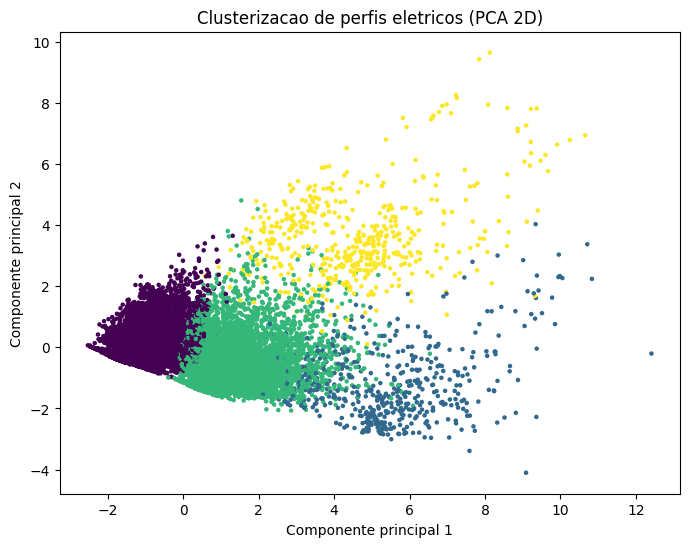

In [12]:
# =========================
# 12. Clusterizacao de perfis eletricos
# =========================

atributos_grupos = [
    COLUNA_ALVO,
    "Global_reactive_power",
    "Voltage",
    "Global_intensity",
    "Sub_metering_1",
    "Sub_metering_2",
    "Sub_metering_3",
]

atributos_grupos = [coluna for coluna in atributos_grupos if coluna in dados.columns]
dados_grupos = dados[atributos_grupos].dropna().copy()

if len(dados_grupos) > 1000 and len(atributos_grupos) >= 2:
    amostra_grupos = dados_grupos.sample(min(20000, len(dados_grupos)), random_state=SEMENTE_ALEATORIA)

    padronizador = StandardScaler()
    atributos_padronizados = padronizador.fit_transform(amostra_grupos)

    modelo_kmeans = KMeans(n_clusters=QUANTIDADE_GRUPOS, random_state=SEMENTE_ALEATORIA, n_init=10)
    amostra_grupos["grupo"] = modelo_kmeans.fit_predict(atributos_padronizados)

    resumo_grupos = amostra_grupos.groupby("grupo")[atributos_grupos].mean()
    display(renomear_para_exibicao(resumo_grupos))

    modelo_pca = PCA(n_components=2, random_state=SEMENTE_ALEATORIA)
    componentes_pca = modelo_pca.fit_transform(atributos_padronizados)

    plt.figure(figsize=(8, 6))
    plt.scatter(componentes_pca[:, 0], componentes_pca[:, 1], c=amostra_grupos["grupo"], s=5)
    plt.title("Clusterizacao de perfis eletricos (PCA 2D)")
    plt.xlabel("Componente principal 1")
    plt.ylabel("Componente principal 2")
    plt.show()
else:
    print("Dados insuficientes para clusterizacao.")


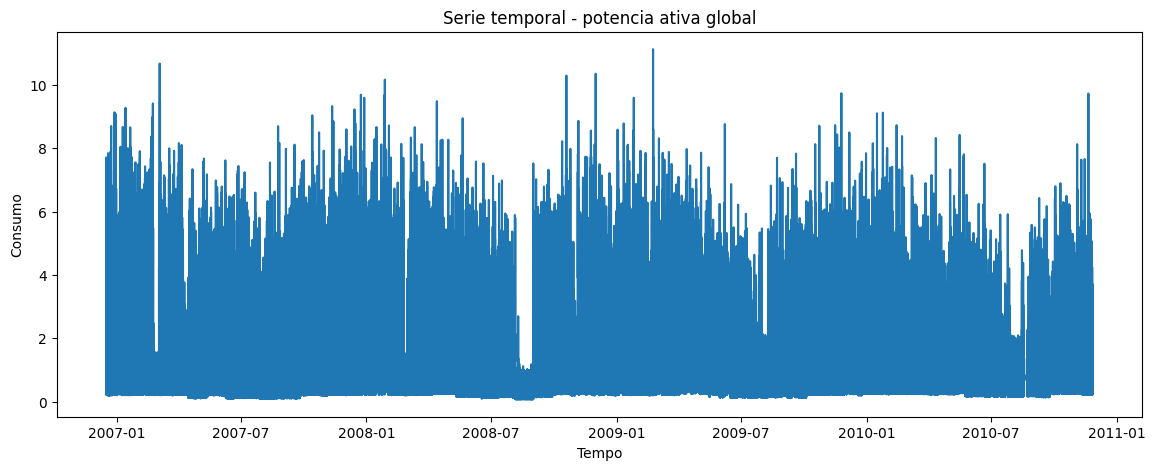

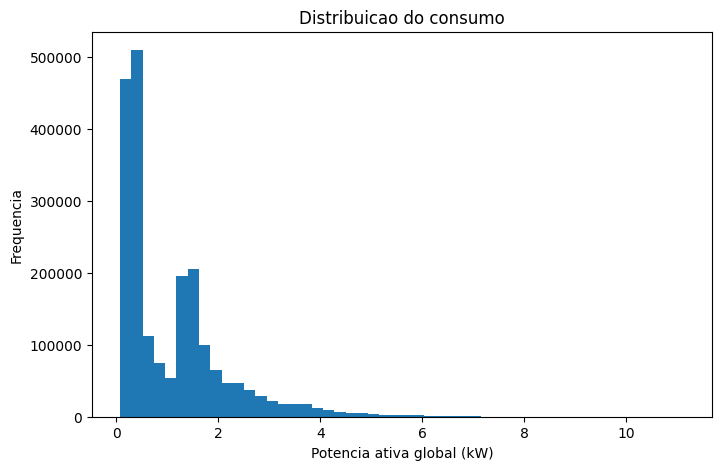

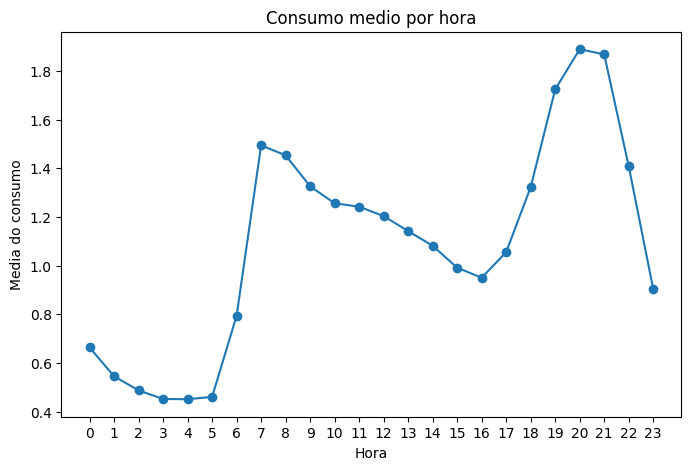

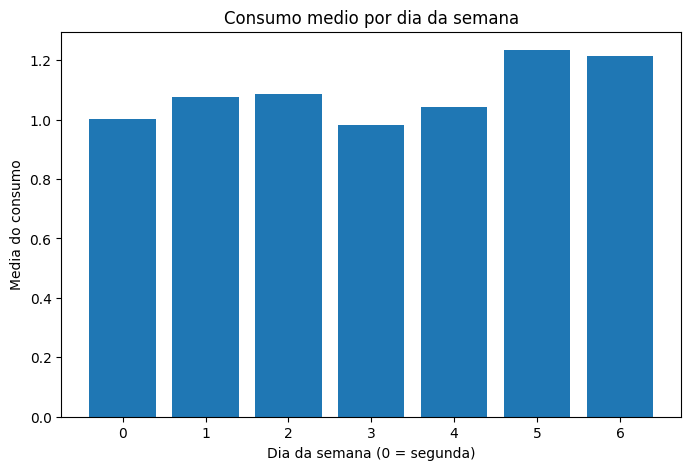

In [13]:
# =========================
# 13. Visualizacoes principais
# =========================

plt.figure(figsize=(14, 5))
plt.plot(dados.index, dados[COLUNA_ALVO])
plt.title("Serie temporal - potencia ativa global")
plt.xlabel("Tempo")
plt.ylabel("Consumo")
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(dados[COLUNA_ALVO].dropna(), bins=50)
plt.title("Distribuicao do consumo")
plt.xlabel(NOMES_EXIBICAO[COLUNA_ALVO])
plt.ylabel("Frequencia")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(perfil_por_hora.index, perfil_por_hora["mean"], marker="o")
plt.title("Consumo medio por hora")
plt.xlabel("Hora")
plt.ylabel("Media do consumo")
plt.xticks(range(0, 24))
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(perfil_por_dia_semana.index.astype(str), perfil_por_dia_semana["mean"])
plt.title("Consumo medio por dia da semana")
plt.xlabel("Dia da semana (0 = segunda)")
plt.ylabel("Media do consumo")
plt.show()


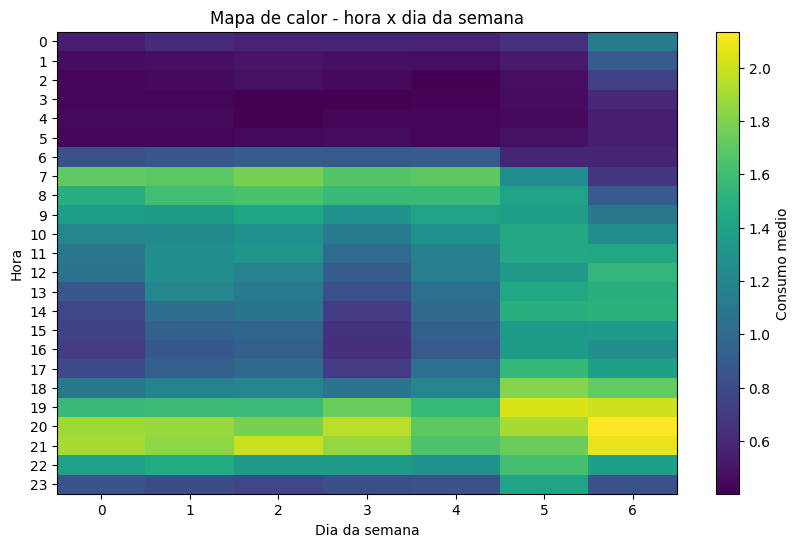

dia_semana,0,1,2,3,4,5,6
hora,,,,,,,
0,0.540659,0.614100,0.570861,0.579065,0.568513,0.647519,1.123132
1,0.460930,0.474125,0.495400,0.475284,0.468289,0.530669,0.908120
2,0.424626,0.446205,0.482387,0.446475,0.413553,0.465604,0.728709
3,0.435075,0.433233,0.402163,0.407886,0.418174,0.460731,0.603909
4,0.439967,0.447202,0.413392,0.435008,0.431234,0.439014,0.547781


In [14]:
# =========================
# 14. Mapa de calor por hora x dia da semana
# =========================

tabela_hora_dia = dados.pivot_table(
    index="hora",
    columns="dia_semana",
    values=COLUNA_ALVO,
    aggfunc="mean",
)

plt.figure(figsize=(10, 6))
plt.imshow(tabela_hora_dia, aspect="auto")
plt.colorbar(label="Consumo medio")
plt.title("Mapa de calor - hora x dia da semana")
plt.xlabel("Dia da semana")
plt.ylabel("Hora")
plt.xticks(ticks=range(len(tabela_hora_dia.columns)), labels=tabela_hora_dia.columns)
plt.yticks(ticks=range(len(tabela_hora_dia.index)), labels=tabela_hora_dia.index)
plt.show()

display(tabela_hora_dia.head())


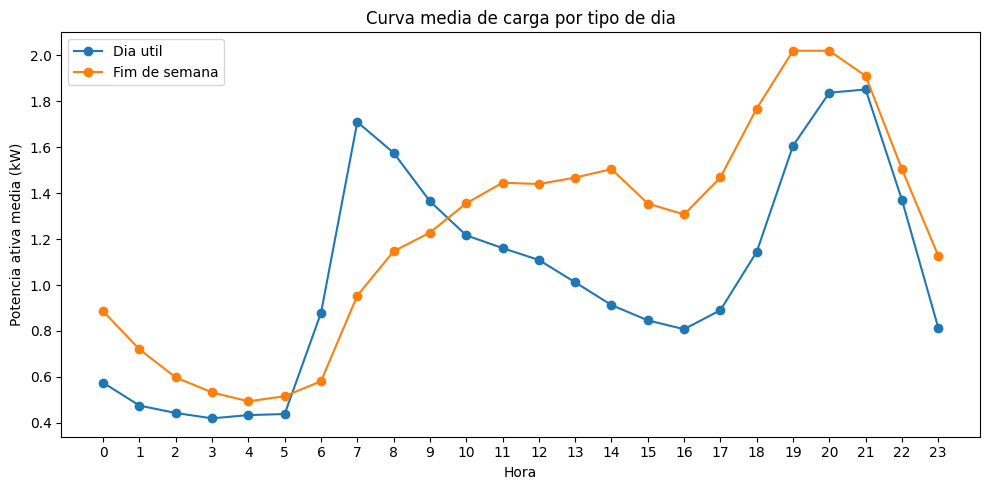

fim_de_semana,Dia util,Fim de semana
hora,,
0,0.575,0.886
1,0.475,0.720
2,0.443,0.597
3,0.419,0.532
4,0.433,0.494
5,0.438,0.516
6,0.879,0.581
7,1.710,0.954
8,1.576,1.147


In [15]:
# =========================
# 15. Curva de carga por tipo de dia
# =========================

perfil_horario_tipo_dia = dados.groupby(["fim_de_semana", "hora"])[COLUNA_ALVO].mean().unstack(0)
perfil_horario_tipo_dia = perfil_horario_tipo_dia.rename(columns={0: "Dia util", 1: "Fim de semana"})

plt.figure(figsize=(10, 5))
for coluna in perfil_horario_tipo_dia.columns:
    plt.plot(perfil_horario_tipo_dia.index, perfil_horario_tipo_dia[coluna], marker="o", label=coluna)
plt.title("Curva media de carga por tipo de dia")
plt.xlabel("Hora")
plt.ylabel("Potencia ativa media (kW)")
plt.xticks(range(0, 24))
plt.legend()
plt.tight_layout()
plt.show()

display(perfil_horario_tipo_dia.round(3))


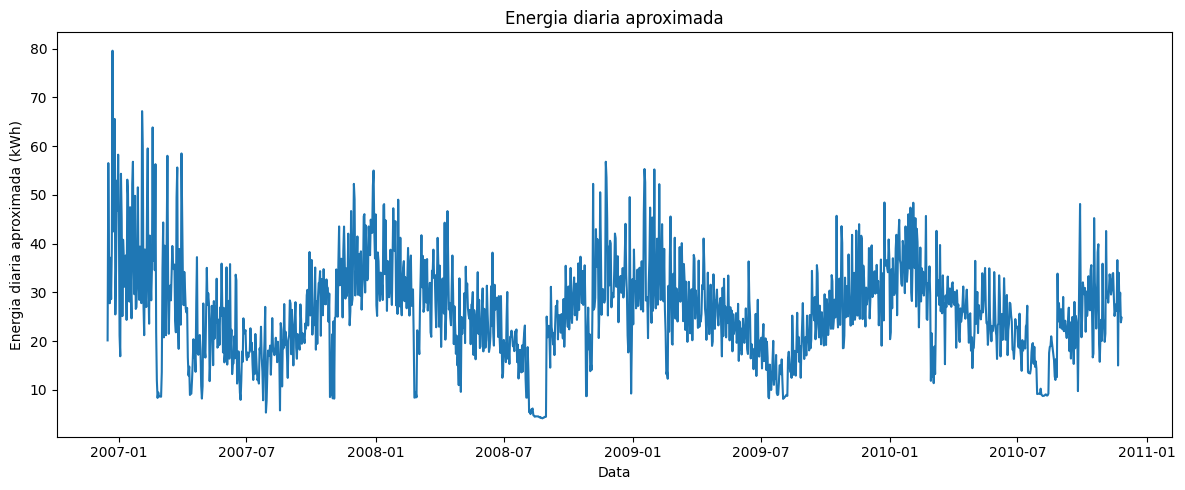

Dias com maior energia diaria aproximada:


,energia_diaria_aprox_kwh,potencia_media_diaria_kw,potencia_maxima_diaria_kw
data_hora,,,
2006-12-23,79.556433,3.314851,8.698
2007-02-03,67.162033,2.798418,7.904
2006-12-26,65.568500,2.732021,6.496
2007-02-18,63.829367,2.659557,7.160
2007-02-04,59.932333,2.497181,7.698
2007-02-11,59.520467,2.480019,7.426
2007-03-31,58.491833,2.437160,7.098
2006-12-31,58.236600,2.426525,6.722
2007-03-11,58.010600,2.417108,7.142


Dias com menor energia diaria aproximada:


,energia_diaria_aprox_kwh,potencia_media_diaria_kw,potencia_maxima_diaria_kw
data_hora,,,
2008-08-25,4.171633,0.173818,0.958
2008-08-23,4.244033,0.176835,1.020
2008-08-24,4.245267,0.176886,0.912
2008-08-26,4.292733,0.178864,0.952
2008-08-27,4.301900,0.179246,1.006
2008-08-21,4.354967,0.181457,0.926
2008-08-22,4.452067,0.185503,1.020
2008-08-29,4.459800,0.185825,0.924
2008-08-28,4.470767,0.186282,1.180


In [16]:
# =========================
# 16. Consumo diario e ranking de dias
# =========================

consumo_diario = pd.DataFrame({
    "energia_diaria_aprox_kwh": dados[COLUNA_ALVO].resample("D").sum() / 60,
    "potencia_media_diaria_kw": dados[COLUNA_ALVO].resample("D").mean(),
    "potencia_maxima_diaria_kw": dados[COLUNA_ALVO].resample("D").max(),
})

maiores_consumos_diarios = consumo_diario.sort_values("energia_diaria_aprox_kwh", ascending=False).head(10)
menores_consumos_diarios = consumo_diario.sort_values("energia_diaria_aprox_kwh", ascending=True).head(10)

plt.figure(figsize=(12, 5))
plt.plot(consumo_diario.index, consumo_diario["energia_diaria_aprox_kwh"])
plt.title("Energia diaria aproximada")
plt.xlabel("Data")
plt.ylabel("Energia diaria aproximada (kWh)")
plt.tight_layout()
plt.show()

print("Dias com maior energia diaria aproximada:")
display(maiores_consumos_diarios)
print("Dias com menor energia diaria aproximada:")
display(menores_consumos_diarios)


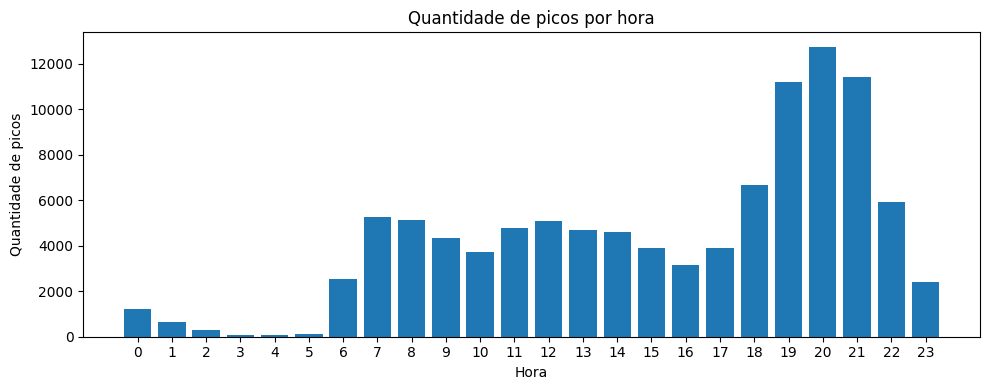

Limiar adotado para pico (percentil 95): 3.246 kW
Horas com mais eventos de pico:


,quantidade_picos
hora,
20,12743
21,11402
19,11176
18,6651
22,5944
7,5272
8,5113
12,5101
11,4786


Maiores picos observados:


,Global_active_power,periodo_dia,dia_semana
data_hora,,,
2009-02-22 17:09:00,11.122,tarde,6
2007-03-04 19:34:00,10.670,noite,6
2007-03-04 19:33:00,10.650,noite,6
2009-02-22 17:08:00,10.536,tarde,6
2008-11-30 20:19:00,10.348,noite,6
2008-10-19 01:24:00,10.290,madrugada,6
2008-01-27 19:24:00,10.162,noite,6
2007-03-04 19:32:00,10.154,noite,6
2008-11-30 20:17:00,10.074,noite,6


In [17]:
# =========================
# 17. Picos de consumo
# =========================

limiar_pico = dados[COLUNA_ALVO].quantile(0.95)
eventos_pico = dados[dados[COLUNA_ALVO] >= limiar_pico].copy()
quantidade_picos_por_hora = eventos_pico.groupby("hora")[COLUNA_ALVO].count().to_frame("quantidade_picos")
maiores_picos = eventos_pico[[COLUNA_ALVO, "periodo_dia", "dia_semana"]].sort_values(COLUNA_ALVO, ascending=False).head(15)

plt.figure(figsize=(10, 4))
plt.bar(quantidade_picos_por_hora.index.astype(str), quantidade_picos_por_hora["quantidade_picos"])
plt.title("Quantidade de picos por hora")
plt.xlabel("Hora")
plt.ylabel("Quantidade de picos")
plt.tight_layout()
plt.show()

print(f"Limiar adotado para pico (percentil 95): {limiar_pico:.3f} kW")
print("Horas com mais eventos de pico:")
display(quantidade_picos_por_hora.sort_values("quantidade_picos", ascending=False).head(10))
print("Maiores picos observados:")
display(maiores_picos)


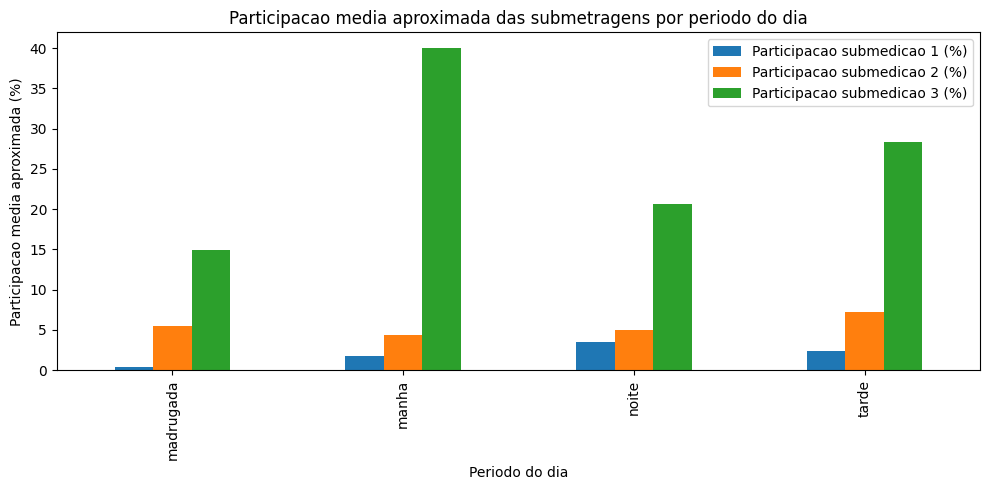

,Participacao submedicao 1 (%),Participacao submedicao 2 (%),Participacao submedicao 3 (%)
periodo_dia,,,
madrugada,0.35,5.47,14.96
manha,1.78,4.41,39.97
noite,3.56,5.01,20.63
tarde,2.40,7.28,28.40


In [18]:
# =========================
# 18. Participacao aproximada das submetragens
# =========================

colunas_submedicao = [coluna for coluna in ["Sub_metering_1", "Sub_metering_2", "Sub_metering_3"] if coluna in dados.columns]
energia_total_minuto_wh_aprox = dados[COLUNA_ALVO] * 1000 / 60

dados_participacao = dados.copy()
for coluna in colunas_submedicao:
    nome_coluna = f"participacao_{coluna.lower()}_pct"
    dados_participacao[nome_coluna] = np.where(
        energia_total_minuto_wh_aprox > 0,
        100 * dados_participacao[coluna] / energia_total_minuto_wh_aprox,
        np.nan,
    )

colunas_participacao = [coluna for coluna in dados_participacao.columns if coluna.startswith("participacao_sub_metering")]
participacao_media_por_periodo = dados_participacao.groupby("periodo_dia")[colunas_participacao].mean()
participacao_media_por_periodo = participacao_media_por_periodo.rename(columns={
    "participacao_sub_metering_1_pct": "Participacao submedicao 1 (%)",
    "participacao_sub_metering_2_pct": "Participacao submedicao 2 (%)",
    "participacao_sub_metering_3_pct": "Participacao submedicao 3 (%)",
})

participacao_media_por_periodo.plot(kind="bar", figsize=(10, 5))
plt.title("Participacao media aproximada das submetragens por periodo do dia")
plt.xlabel("Periodo do dia")
plt.ylabel("Participacao media aproximada (%)")
plt.tight_layout()
plt.show()

display(participacao_media_por_periodo.round(2))


In [19]:
# =========================
# 19. Dias extremos de consumo e submetragens
# =========================

submedicoes_diarias = dados[colunas_submedicao].resample("D").sum() if colunas_submedicao else pd.DataFrame(index=consumo_diario.index)
base_diaria_completa = consumo_diario.join(submedicoes_diarias, how="left")

data_maior_consumo = base_diaria_completa["energia_diaria_aprox_kwh"].idxmax()
data_menor_consumo = base_diaria_completa["energia_diaria_aprox_kwh"].idxmin()

resumos_dias_extremos = []
for rotulo, data_ref in [("maior_consumo", data_maior_consumo), ("menor_consumo", data_menor_consumo)]:
    linha = base_diaria_completa.loc[data_ref]
    submeticoes_do_dia = linha[colunas_submedicao].dropna() if colunas_submedicao else pd.Series(dtype=float)

    if not submeticoes_do_dia.empty:
        submedicao_maior = submeticoes_do_dia.idxmax()
        submedicao_menor = submeticoes_do_dia.idxmin()
        valor_submedicao_maior = submeticoes_do_dia.max()
        valor_submedicao_menor = submeticoes_do_dia.min()
    else:
        submedicao_maior = np.nan
        submedicao_menor = np.nan
        valor_submedicao_maior = np.nan
        valor_submedicao_menor = np.nan

    resumos_dias_extremos.append({
        "tipo_dia": rotulo,
        "data": data_ref.date(),
        "ano": data_ref.year,
        "mes": data_ref.month,
        "dia": data_ref.day,
        "dia_semana_nome": data_ref.day_name(),
        "energia_diaria_aprox_kwh": linha["energia_diaria_aprox_kwh"],
        "potencia_media_diaria_kw": linha["potencia_media_diaria_kw"],
        "potencia_maxima_diaria_kw": linha["potencia_maxima_diaria_kw"],
        "submedicao_maior": submedicao_maior,
        "valor_submedicao_maior_wh": valor_submedicao_maior,
        "submedicao_menor": submedicao_menor,
        "valor_submedicao_menor_wh": valor_submedicao_menor,
    })

resumo_dias_extremos = pd.DataFrame(resumos_dias_extremos)
resumo_dias_extremos["submedicao_maior"] = resumo_dias_extremos["submedicao_maior"].replace(NOMES_EXIBICAO)
resumo_dias_extremos["submedicao_menor"] = resumo_dias_extremos["submedicao_menor"].replace(NOMES_EXIBICAO)

print("Resumo dos dias extremos de consumo:")
display(resumo_dias_extremos)


Resumo dos dias extremos de consumo:


,tipo_dia,data,ano,mes,dia,dia_semana_nome,energia_diaria_aprox_kwh,potencia_media_diaria_kw,potencia_maxima_diaria_kw,submedicao_maior,valor_submedicao_maior_wh,submedicao_menor,valor_submedicao_menor_wh
0,maior_consumo,2006-12-23,2006,12,23,Saturday,79.556433,3.314851,8.698,Submedicao 3 - aquecimento/climatizacao (Wh),14726.0,Submedicao 2 - lavanderia (Wh),425.0
1,menor_consumo,2008-08-25,2008,8,25,Monday,4.171633,0.173818,0.958,Submedicao 3 - aquecimento/climatizacao (Wh),1436.0,Submedicao 1 - cozinha (Wh),0.0


In [20]:
# =========================
# 15. Tabelas para interpretacao por LLM
# =========================

tabelas_insumo_llm = {
    "perfil_por_hora": perfil_por_hora.reset_index(),
    "perfil_por_dia_semana": perfil_por_dia_semana.reset_index(),
    "perfil_por_mes": perfil_por_mes.reset_index(),
    "tabela_por_periodo": tabela_por_periodo.reset_index(),
    "tabela_por_regime": tabela_por_regime.reset_index(),
    "correlacao_alvo": correlacao_alvo.reset_index(),
    "perfil_horario_tipo_dia": perfil_horario_tipo_dia.reset_index(),
    "consumo_diario": consumo_diario.reset_index(),
    "quantidade_picos_por_hora": quantidade_picos_por_hora.reset_index(),
    "participacao_media_por_periodo": participacao_media_por_periodo.reset_index(),
    "resumo_dias_extremos": resumo_dias_extremos.reset_index(drop=True),
}

for nome_tabela, tabela in tabelas_insumo_llm.items():
    print(f"\nTabela: {nome_tabela}")
    display(renomear_para_exibicao(tabela.head(10)))



Tabela: perfil_por_hora


,Hora,mean,median,std,min,max,count
0,0,0.663418,0.368,0.716996,0.078,7.698,86460
1,1,0.544698,0.330,0.587069,0.078,10.290,86460
2,2,0.486809,0.322,0.492417,0.078,6.248,86460
3,3,0.451589,0.316,0.435932,0.078,4.426,86460
4,4,0.450522,0.314,0.431222,0.078,4.796,86460
5,5,0.460220,0.312,0.451441,0.078,6.376,86460
6,6,0.793647,0.352,0.925205,0.078,8.310,86460
7,7,1.494386,1.492,1.078613,0.078,9.486,86460
8,8,1.453509,1.408,0.947890,0.078,8.126,86460
9,9,1.326026,1.358,0.853924,0.078,7.732,86460



Tabela: perfil_por_dia_semana


,Dia da semana,mean,median,std,min,max,count
0,0,1.001749,0.512,0.953902,0.078,9.486,296640
1,1,1.074770,0.620,1.017971,0.076,9.732,296640
2,2,1.085026,0.630,1.022656,0.078,8.974,296640
3,3,0.982072,0.498,0.955240,0.076,9.410,296640
4,4,1.042086,0.628,0.968380,0.078,9.590,296463
5,5,1.233651,0.784,1.182201,0.078,9.724,295596
6,6,1.213079,0.680,1.208122,0.078,11.122,296640



Tabela: perfil_por_mes


...

,Hora,quantidade_picos
0,0,1237
1,1,646
2,2,283
3,3,89
4,4,93
5,5,113
6,6,2559
7,7,5272
8,8,5113
9,9,4319



Tabela: participacao_media_por_periodo


,Periodo do dia,Participacao submedicao 1 (%),Participacao submedicao 2 (%),Participacao submedicao 3 (%)
0,madrugada,0.353719,5.465485,14.955956
1,manha,1.777654,4.411367,39.969555
2,noite,3.557887,5.007671,20.629604
3,tarde,2.402889,7.280732,28.401852



Tabela: resumo_dias_extremos


,tipo_dia,data,Ano,Mes,Dia,dia_semana_nome,energia_diaria_aprox_kwh,potencia_media_diaria_kw,potencia_maxima_diaria_kw,submedicao_maior,valor_submedicao_maior_wh,submedicao_menor,valor_submedicao_menor_wh
0,maior_consumo,2006-12-23,2006,12,23,Saturday,79.556433,3.314851,8.698,Submedicao 3 - aquecimento/climatizacao (Wh),14726.0,Submedicao 2 - lavanderia (Wh),425.0
1,menor_consumo,2008-08-25,2008,8,25,Monday,4.171633,0.173818,0.958,Submedicao 3 - aquecimento/climatizacao (Wh),1436.0,Submedicao 1 - cozinha (Wh),0.0


In [21]:
# =========================
# 16. Resumo automatico inicial
# =========================

hora_pico = perfil_por_hora["mean"].idxmax()
hora_minima = perfil_por_hora["mean"].idxmin()
top_correlacoes = correlacao_alvo.drop(index=COLUNA_ALVO, errors="ignore").head(3)

print("Resumo exploratorio inicial:")
print(f"- Hora de maior consumo medio: {hora_pico}")
print(f"- Hora de menor consumo medio: {hora_minima}")
print(f"- Regimes encontrados: {dados['regime_consumo'].dropna().unique().tolist()}")
print(f"- Limiar de pico adotado (percentil 95): {limiar_pico:.3f} kW")
print(f"- Dia com maior energia diaria aproximada: {consumo_diario['energia_diaria_aprox_kwh'].idxmax().date()}")
print(f"- Dia com menor energia diaria aproximada: {consumo_diario['energia_diaria_aprox_kwh'].idxmin().date()}")
print("- Variaveis mais correlacionadas com o consumo total:")
display(renomear_para_exibicao(top_correlacoes))


Resumo exploratorio inicial:
- Hora de maior consumo medio: 20
- Hora de menor consumo medio: 4
- Regimes encontrados: ['alto', 'moderado', 'baixo']
- Limiar de pico adotado (percentil 95): 3.246 kW
- Dia com maior energia diaria aproximada: 2006-12-23
- Dia com menor energia diaria aproximada: 2008-08-25
- Variaveis mais correlacionadas com o consumo total:


,Potencia ativa global (kW)
Consumo nao medido aprox. (kW),0.999979
Corrente global (A),0.998887
Submedicao total (Wh),0.847112


---
## Analises Avancadas

Seção complementar com técnicas avançadas de séries temporais e diagnóstico elétrico.


In [22]:
# =========================
# 21. Decomposicao de serie temporal
# =========================

from statsmodels.tsa.seasonal import seasonal_decompose

# Reamostrar para media diaria (serie original tem granularidade por minuto,
# o que tornaria a decomposicao muito pesada)
serie_diaria = dados[COLUNA_ALVO].resample("D").mean().dropna()

decomposicao = seasonal_decompose(serie_diaria, model="additive", period=7)

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

decomposicao.observed.plot(ax=axes[0], title="Sinal Observado")
axes[0].set_ylabel("kW")

decomposicao.trend.plot(ax=axes[1], title="Tendencia")
axes[1].set_ylabel("kW")

decomposicao.seasonal.plot(ax=axes[2], title="Sazonalidade (periodo = 7 dias)")
axes[2].set_ylabel("kW")

decomposicao.resid.plot(ax=axes[3], title="Residuos")
axes[3].set_ylabel("kW")

plt.suptitle("Decomposicao Aditiva da Potencia Ativa Media Diaria", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print(f"Amplitude da sazonalidade semanal: {decomposicao.seasonal.max() - decomposicao.seasonal.min():.4f} kW")


ModuleNotFoundError: No module named 'statsmodels'

In [ ]:
# =========================
# 22. Autocorrelacao (ACF / PACF)
# =========================

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(serie_diaria, lags=60, ax=axes[0], title="ACF – Potencia Ativa Media Diaria")
plot_pacf(serie_diaria, lags=60, ax=axes[1], title="PACF – Potencia Ativa Media Diaria", method="ywm")

axes[0].set_xlabel("Lag (dias)")
axes[1].set_xlabel("Lag (dias)")

plt.tight_layout()
plt.show()

print("Interpretacao:")
print("  - Picos no ACF em multiplos de 7 confirmam sazonalidade semanal.")
print("  - O decaimento lento do ACF sugere tendencia no sinal.")


In [ ]:
# =========================
# 23. Heatmap: Hora do Dia x Dia da Semana
# =========================

import seaborn as sns

tabela_pivot = dados.pivot_table(
    values=COLUNA_ALVO,
    index="hora",
    columns="dia_semana",
    aggfunc="mean",
)

nomes_dias = ["Seg", "Ter", "Qua", "Qui", "Sex", "Sab", "Dom"]
tabela_pivot.columns = nomes_dias

plt.figure(figsize=(10, 8))
sns.heatmap(
    tabela_pivot,
    cmap="YlOrRd",
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"label": "Potencia media (kW)"},
)
plt.title("Potencia Ativa Media por Hora e Dia da Semana")
plt.xlabel("Dia da Semana")
plt.ylabel("Hora do Dia")
plt.tight_layout()
plt.show()


In [ ]:
# =========================
# 24. Assinatura Energetica: Tensao x Potencia Ativa
# =========================

# Usar amostra para performance (2 milhoes de pontos e pesado para scatter)
amostra_assinatura = dados[["Voltage", COLUNA_ALVO]].dropna().sample(
    n=min(50_000, len(dados)), random_state=SEMENTE_ALEATORIA
)

plt.figure(figsize=(10, 6))
plt.scatter(
    amostra_assinatura["Voltage"],
    amostra_assinatura[COLUNA_ALVO],
    alpha=0.08,
    s=3,
    c="steelblue",
)
plt.title("Assinatura Energetica: Tensao x Potencia Ativa")
plt.xlabel("Tensao (V)")
plt.ylabel("Potencia Ativa (kW)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Interpretacao:")
print("  - Regioes densas indicam estados operacionais tipicos.")
print("  - Se houver 'faixas' verticais distintas, indicam patamares de carga.")


In [ ]:
# =========================
# 25. Potencia Ativa x Reativa (Proxy de Fator de Potencia)
# =========================

amostra_fp = dados[[COLUNA_ALVO, "Global_reactive_power"]].dropna().sample(
    n=min(50_000, len(dados)), random_state=SEMENTE_ALEATORIA
)

plt.figure(figsize=(10, 6))
plt.scatter(
    amostra_fp[COLUNA_ALVO],
    amostra_fp["Global_reactive_power"],
    alpha=0.08,
    s=3,
    c="darkorange",
)
plt.title("Potencia Ativa x Reativa (diagrama P-Q)")
plt.xlabel("Potencia Ativa (kW)")
plt.ylabel("Potencia Reativa (kvar)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Calculo do fator de potencia medio
p = dados[COLUNA_ALVO]
q = dados["Global_reactive_power"]
s = np.sqrt(p**2 + q**2)
fp = (p / s).replace([np.inf, -np.inf], np.nan).dropna()

print(f"Fator de potencia medio estimado: {fp.mean():.4f}")
print(f"Fator de potencia mediano: {fp.median():.4f}")
print("Interpretacao:")
print("  - Valores proximos de 1.0 indicam carga predominantemente resistiva.")
print("  - Valores abaixo de 0.92 sugerem margem para correcao com capacitores.")


In [ ]:
# =========================
# 17. Exportacao opcional
# =========================

EXPORTAR_PARQUET = False
EXPORTAR_CSV = False

if EXPORTAR_CSV:
    perfil_por_hora.to_csv("perfil_por_hora.csv", index=True)
    perfil_por_dia_semana.to_csv("perfil_por_dia_semana.csv", index=True)
    perfil_por_mes.to_csv("perfil_por_mes.csv", index=True)
    tabela_por_periodo.to_csv("tabela_por_periodo.csv", index=True)
    tabela_por_regime.to_csv("tabela_por_regime.csv", index=True)
    tabela_anomalias.to_csv("tabela_anomalias.csv", index=False)
    dados.to_csv("dados_enriquecidos_consumo_energia.csv", index=True)

if EXPORTAR_PARQUET:
    dados.to_parquet("dados_enriquecidos_consumo_energia.parquet")
